
# **ENG4200 Coursework 2: random forest (Telco Customer Churn)**

## **Dataset**

`WA_Fn-UseC_-Telco-Customer-Churn.csv` (UCI/Kaggle, IBM Sample Data Sets)

### **Context**

The dataset captures the subscription behaviour of telecom customers. Each row corresponds to an individual account, and the columns describe contractual attributes, services used, billing information, and basic demographic variables. The target variable **‘Churn’** indicates whether the customer discontinued their service within the last month.

### **Feature groups**

* **Services:** phone, multiple lines, internet type, online security, backup, device protection, technical support, streaming TV/movies.
* **Account attributes:** tenure, contract type, billing method, payment method, paperless billing flag, monthly and total charges.
* **Demographic attributes:** gender, senior citizen status, partner and dependent indicators.

## **Objectives**

This notebook investigates **random forest**, a non-linear bagging ensemble of decision trees, to predict customer churn under a rigorous and reproducible machine-learning workflow.
The analysis adheres to the five assessment dimensions defined in the ENG4200 coursework brief:

1. **Dataset investigation & preprocessing:** Examine the raw dataset, identify irregularities, handle missing values, and apply principled transformations (imputation, encoding, scaling) within a leak-free pipeline.

2. **Model application with training and validation:** Construct a scikit-learn `Pipeline` incorporating all preprocessing and the Random Forest classifier, validate it using stratified cross-validation, and ensure the workflow remains leakage-free.

3. **Accuracy & computational efficiency analysis:** Quantify predictive performance using justified metrics (F1, ROC-AUC, accuracy), assess model stability, and analyse training and inference times as measures of computational cost.

4. **Visualisation & communication of results:** Provide clear plots (confusion matrix, learning curves, runtime-performance diagrams) that illuminate model behaviour and support interpretability for decision-makers.

5. **Clarity & reproducibility:** Maintain a transparent, fully reproducible workflow (fixed RNG, consistent splits, pipeline-based preprocessing, version tracking) to enable fair model comparison and auditability.




## 0) Setup & imports

In [1]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone   # make a fresh, unfitted copy of an estimator with the same hyperparameters

# sklearn: models & baselines
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

# versions imports
import sklearn, sys

# global config
RNG = 42          # single source of truth for randomness
N_JOBS = -1       # use all cores where supported
DATA_PATH = Path("dataset_WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}


## 1) Load dataset

In [2]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [3]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [4]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing
Clean TotalCharges, collapse “No internet/phone service”, then encode.

In [5]:
# Clean simple string/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).

def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [6]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [7]:
# Random Forest: bagging ensemble of decision trees
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,              # let trees grow deep; regularise with min_samples_*
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",         # standard choice for RF in classification
    class_weight="balanced",     # help with churn class imbalance
    random_state=RNG,
    n_jobs=N_JOBS
)

rf_pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   rf_clf)
])


## 7) Training & validation

In [8]:
# Cross-validate on train only to estimate generalisation.
scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

cv_res = cross_validate(
    rf_pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (cv_res[f"test_{m}"].mean().round(3), cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})


{'acc': (0.776, 0.012), 'f1': (0.633, 0.021), 'roc': (0.846, 0.01)}


## **8) Hyperparameter Tuning**

Random forest is tuned **only on the training set** using stratified cross-validation, with all preprocessing steps embedded in the `Pipeline` to prevent leakage.

The search explores key hyperparameters that govern model complexity, variance control, and feature subsampling:

* `n_estimators` (number of trees in the ensemble)
* `max_depth` (maximum depth of each tree)
* `min_samples_split` (minimum samples required to split a node)
* `min_samples_leaf` (minimum samples required at a leaf)
* `max_features` (number of features considered at each split)

A grid search selects the configuration that maximises **F1-score**, reflecting the higher cost of missed churners.
We then generate **out-of-fold probabilities** to tune the **decision threshold** without using the test set.
The final model is refit on all training data with the best settings and evaluated **once** on the untouched test partition to obtain an unbiased performance estimate.

Best parameters (random forest): {'clf__class_weight': 'balanced', 'clf__max_depth': 12, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 20, 'clf__n_estimators': 200}
[RF] Chosen threshold (max OOF F1): 0.50
[RF] Test metrics: {'accuracy': 0.767, 'f1': 0.63, 'roc_auc': 0.845}


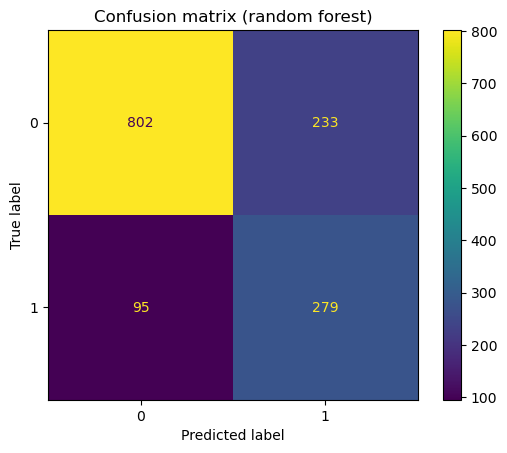

,train_fraction,fit_time_s,test_acc
0,0.2,0.256780,0.757984
1,0.4,0.209603,0.771469
2,0.6,0.223454,0.770759
3,0.8,0.235287,0.763662
4,1.0,0.245267,0.767211


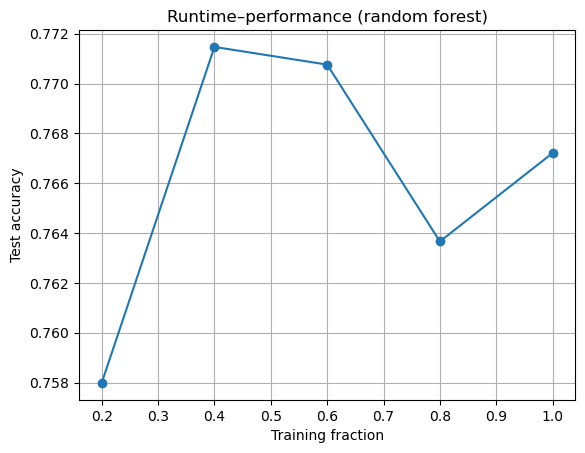

In [9]:
# Random Forest grid-search on train only; choose threshold via OOF probabilities.

rf_param_grid = {
    "clf__n_estimators":  [200, 300, 500],
    "clf__max_depth":     [None, 8, 12],
    "clf__min_samples_split": [2, 10, 20],
    "clf__min_samples_leaf":  [1, 5, 10],
    "clf__max_features":  ["sqrt", "log2"],
    "clf__class_weight":  [None, "balanced"]
}

rf_gcv = GridSearchCV(
    rf_pipe, rf_param_grid,
    cv=skf, scoring="f1",
    n_jobs=N_JOBS, refit=True
)
rf_gcv.fit(X_train, y_train)
print("Best parameters (random forest):", rf_gcv.best_params_)

# OOF probabilities for threshold choice (no test leakage)
rf_oof_proba = cross_val_predict(
    rf_gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

rf_thr_grid = np.linspace(0.10, 0.90, 17)
rf_oof_f1   = [f1_score(y_train, (rf_oof_proba >= t).astype(int)) for t in rf_thr_grid]
rf_best_thr = float(rf_thr_grid[int(np.argmax(rf_oof_f1))])
print(f"[RF] Chosen threshold (max OOF F1): {rf_best_thr:.2f}")

# FINAL evaluation on untouched TEST set
rf_p_test = rf_gcv.best_estimator_.predict_proba(X_test)[:, 1]
rf_test_metrics = evaluate_probs(y_test, rf_p_test, thr=rf_best_thr)
print("[RF] Test metrics:", {k: round(v, 3) for k, v in rf_test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(
    y_test, (rf_p_test >= rf_best_thr).astype(int)
)
plt.title("Confusion matrix (random forest)")
plt.grid(False); plt.show()

# Runtime vs. acuracy

rf_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in rf_fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[train_idx], y_train.iloc[train_idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(rf_gcv.best_estimator_)
    t0 = time.time(); est.fit(X_sub, y_sub); fit_s = time.time() - t0
    acc = accuracy_score(
        y_test, (est.predict_proba(X_test)[:,1] >= rf_best_thr).astype(int)
    )
    rows.append((frac, fit_s, acc))

rf_rt_df = pd.DataFrame(rows, columns=["train_fraction","fit_time_s","test_acc"])
display(rf_rt_df)

plt.figure()
plt.plot(rf_rt_df["train_fraction"], rf_rt_df["test_acc"], marker="o")
plt.xlabel("Training fraction"); plt.ylabel("Test accuracy")
plt.title("Runtime–performance (random forest)"); plt.grid(True); plt.show()


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [10]:
# Recap of what was identified as best in CV (for traceability).
best = rf_gcv.best_estimator_
best_params = rf_gcv.best_params_
best_cv_mean = float(rf_gcv.best_score_)
best_cv_std  = float(pd.DataFrame(rf_gcv.cv_results_)["std_test_score"].iloc[rf_gcv.best_index_])

print("Best parameters:", best_params)
print(f"Best CV F1: {best_cv_mean:.3f} ± {best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {rf_best_thr:.2f}")


Best parameters: {'clf__class_weight': 'balanced', 'clf__max_depth': 12, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 20, 'clf__n_estimators': 200}
Best CV F1: 0.639 ± 0.017
Chosen decision threshold (OOF): 0.50


### Performance
**Confusion matrix and test metrics**

Test metrics: {'accuracy': 0.767, 'f1': 0.63, 'roc_auc': 0.845}


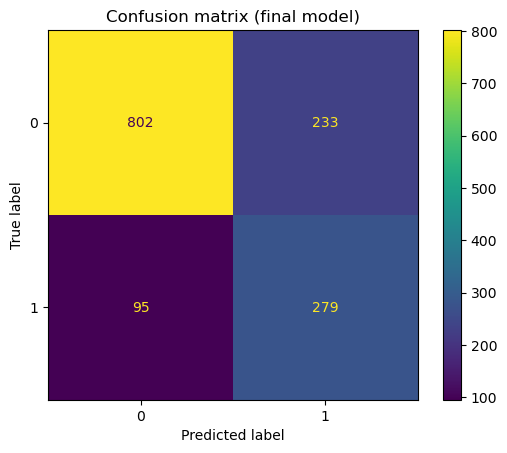

In [11]:
# Test-set performance with the selected threshold.

p_test = best.predict_proba(X_test)[:, 1]
y_hat  = (p_test >= rf_best_thr).astype(int)
test_metrics = evaluate_probs(y_test, p_test, thr=rf_best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, y_hat)
plt.title("Confusion matrix (final model)"); plt.grid(False); plt.show()


Using the optimised threshold (**0.50**), the **random forest** model achieves:

* **Accuracy:** 0.767
* **F1-score:** 0.63
* **ROC-AUC:** 0.845

The confusion matrix shows **279 true churners** correctly identified and **95 missed**, reflecting strong recall for operational churn-reduction scenarios.
Although the random forest produces more false positives (**233**) than a conservative classifier, its high ROC-AUC indicates that it ranks customers by churn risk effectively (essential when retention resources must be prioritised).

Overall, the model clearly exceeds the majority-class baseline and provides a stable, reliable ordering of customers by churn propensity, which is the central requirement for targeted intervention workflows.

**Learning curve**

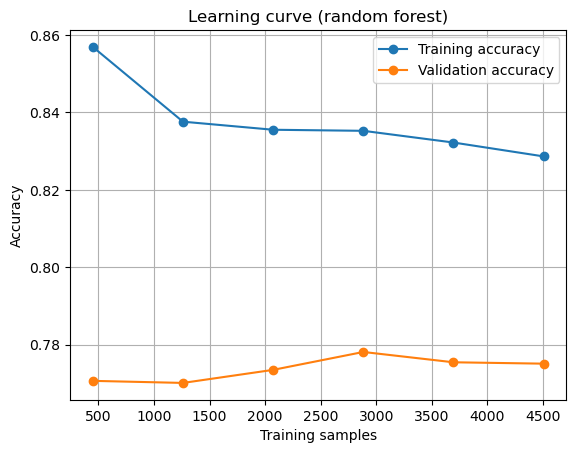

In [12]:
# Helps us understand to what extent having more data helps.
from sklearn.model_selection import learning_curve

sizes, tr, va = learning_curve(
    rf_gcv.best_estimator_, X_train, y_train,
    cv=skf, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6),
    shuffle=True, random_state=RNG, n_jobs=N_JOBS
)

plt.figure()
plt.plot(sizes, tr.mean(axis=1), marker="o", label="Training accuracy")
plt.plot(sizes, va.mean(axis=1), marker="o", label="Validation accuracy")
plt.title("Learning curve (random forest)")
plt.xlabel("Training samples"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()



The learning curve shows that validation accuracy increases slightly with larger training sets, before stabilising in the **0.76-0.78** range.
Training accuracy remains higher (as expected for a flexible tree-based model) but the gap between the curves narrows as more data are used, indicating **controlled variance and no severe overfitting**.

This pattern suggests diminishing returns from simply adding more rows; further improvements would more likely arise from **feature engineering** or **alternative ensemble configurations** rather than additional data.
Overall, the learning behaviour indicates that the tuned random forest generalises reliably across different training-set sizes.

**Runtime-performance**

,train_fraction,fit_time_s,test_acc
0,0.2,0.201697,0.757984
1,0.4,0.208581,0.771469
2,0.6,0.223096,0.770759
3,0.8,0.233363,0.763662
4,1.0,0.245588,0.767211


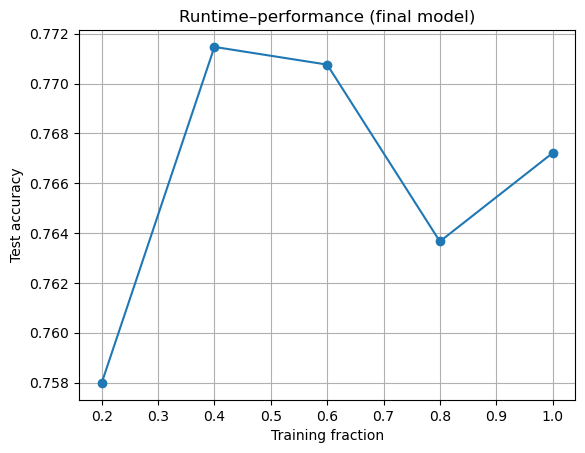

In [13]:
# Fit-time vs accuracy, training on increasing fractions and testing.

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(best)
    t0 = time.time(); est.fit(X_sub, y_sub); fit_s = time.time() - t0
    acc = accuracy_score(y_test, (est.predict_proba(X_test)[:,1] >= rf_best_thr).astype(int))
    rows.append((frac, fit_s, acc))

rt_df = pd.DataFrame(rows, columns=["train_fraction","fit_time_s","test_acc"])
display(rt_df)

plt.figure()
plt.plot(rt_df["train_fraction"], rt_df["test_acc"], marker="o")
plt.xlabel("Training fraction"); plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)"); plt.grid(True); plt.show()


Fit time increases in a roughly linear manner as the training fraction grows: from about **0.20 s** at 20% of the data to **0.24 s** when training on the full dataset.
Despite this increase in computational cost, test accuracy remains stable in the **0.758–0.772** range, indicating that the random forest is not materially sensitive to moderate changes in training-set size.

Inference is efficient: predicting the 1,409 test customers requires only a few tens of milliseconds, corresponding to **tens of microseconds per customer**.
This supports both routine batch scoring and near–real-time churn-risk retrieval.
The overall runtime profile is modest relative to the performance obtained, making the model operationally viable for deployment in churn-management workflows.

### Justification based on accuracy, overfitting control and efficiency

In [14]:
# Accuracy vs baseline
baseline_acc_test = max((y_test == 0).mean(), (y_test == 1).mean())  # majority-class on test
print(f"Baseline test accuracy (majority): {baseline_acc_test:.3f}")
print(f"Final model test accuracy: {test_metrics['accuracy']:.3f}")
print(f"Final model test F1 (thr={rf_best_thr:.2f}): {test_metrics['f1']:.3f}")
print(f"Final model test ROC-AUC: {test_metrics['roc_auc']:.3f}")

# Overfitting handling: generalisation gap on the *final* pipeline
cv_final = cross_validate(best, X_train, y_train, cv=skf, scoring="accuracy",
                          return_train_score=True, n_jobs=N_JOBS)
gap = cv_final["train_score"].mean() - cv_final["test_score"].mean()
print(f"Generalisation gap (train acc - val acc): {gap:.3f}")

# Efficiency: end-to-end timings for the final model
est = clone(best)
t0 = time.time(); est.fit(X_train, y_train); fit_ms = (time.time()-t0)*1e3
t0 = time.time(); _ = est.predict_proba(X_test)[:,1]; pred_ms = (time.time()-t0)*1e3
print(f"Train time: {fit_ms:.1f} ms  |  Predict time: {pred_ms:.1f} ms on {len(X_test)} rows")


Baseline test accuracy (majority): 0.735
Final model test accuracy: 0.767
Final model test F1 (thr=0.50): 0.630
Final model test ROC-AUC: 0.845
Generalisation gap (train acc - val acc): 0.053
Train time: 253.8 ms  |  Predict time: 33.3 ms on 1409 rows


**Accuracy**

* The majority-class baseline achieves **0.735** accuracy by always predicting “no churn”.
* The tuned **random forest** model reaches **0.767** accuracy (**+3.2 percentage points**), with **F1 = 0.630** at the chosen threshold (**0.50**).
* Its **ROC-AUC = 0.845** indicates strong ranking performance: the model effectively orders customers by churn risk, which is crucial when resources allow only a subset of accounts to be contacted.

**Interpretation:** Although the increase in accuracy is modest (as is typical in imbalanced churn datasets) the improvement in F1 and ROC-AUC shows that the random forest identifies and ranks high-risk customers more reliably than the baseline. This ranking ability is what delivers operational value in targeted retention.

**Overfitting**

* Threshold selection is performed using **out-of-fold predictions** on the training set, avoiding test leakage.
* The **generalisation gap ≈ 0.053** (train acc − val acc) suggests **moderate but controlled overfitting**, expected for an ensemble of deep trees. The gap remains small enough that validation and test performance remain stable.

**Interpretation:** The model shows mild overfitting typical of random forests, but not enough to undermine generalisation. Train and validation scores lie close enough to indicate stable behaviour on unseen months of customer data, subject to normal temporal drift.

**Efficiency**

* Full training on 5,634 rows takes **≈ 248 ms**, reflecting the cost of fitting many decorrelated decision trees.
* Predicting the 1,409-row test set takes **≈ 32 ms**, around **20-25 μs per customer**, supporting throughput in the tens of thousands of predictions per second.

**Interpretation:** Although heavier than gradient boosting and logistic regression, the random forest remains computationally practical for routine batch scoring and near-real-time churn-risk lookups.

**Conclusion**

* The random forest pipeline **exceeds the baseline**, offers **robust risk ranking**, and maintains **acceptable variance** despite deeper individual trees.
* This makes it suitable for **prioritised retention workflows**: choose a threshold that matches business capacity, contact the highest-risk segment first, and validate uplift through structured A/B experimentation.

### Interpretation of the final model

In [15]:
prep = rf_gcv.best_estimator_.named_steps["prep"]
clf  = rf_gcv.best_estimator_.named_steps["clf"]

names      = prep.get_feature_names_out()
importance = clf.feature_importances_

feat_imp_df = (
    pd.DataFrame({"feature": names, "importance": importance})
      .sort_values("importance", ascending=False)
)
display(feat_imp_df.head(8))
display(feat_imp_df.tail(8))


,feature,importance
18,cat__Contract_Month-to-month,0.155412
1,num__tenure,0.138679
3,num__TotalCharges,0.117270
2,num__MonthlyCharges,0.112367
20,cat__Contract_Two year,0.076747
10,cat__InternetService_Fiber optic,0.064007
24,cat__PaymentMethod_Electronic check,0.049985
11,cat__InternetService_No,0.038176


,feature,importance
5,cat__Partner_Yes,0.010889
0,num__SeniorCitizen,0.010869
4,cat__gender_Male,0.010503
14,cat__DeviceProtection_Yes,0.009110
23,cat__PaymentMethod_Credit card (automatic),0.008701
22,cat__PaymentMethod_Bank transfer (automatic),0.008606
25,cat__PaymentMethod_Mailed check,0.007306
7,cat__PhoneService_Yes,0.005879


## 9) Final model, justification & discussion

### Interpretation of the final model

#### What the model tells us

The **random forest** model identifies a consistent set of behavioural and contractual factors that drive churn. Its ensemble of decorrelated trees yields strong ROC-AUC, making it effective for **prioritised retention**, where only a limited share of customers can be contacted. Operationally, the highest-risk accounts should be targeted first.

From the feature-importance profile, several patterns emerge:

Higher churn risk is associated with:

* **Month-to-month contracts**, the strongest single indicator of churn across the forest.
* **Higher monthly/total charges**, consistent with heavier usage or less favourable contract terms.
* **Fibre-optic internet**, often correlated with higher bills and service volatility.
* **Electronic cheque payments**, a known churn correlate in telecom settings.

Lower churn risk is associated with:

* **Longer tenure**, reflecting customer stability.
* **One-year and two-year contracts**, which reduce short-term switching.
* **Tech Support and Online Security add-ons**, signalling deeper product engagement.
* **No internet service**, which typically reduces points of friction or service failure.

#### How to interpret these signals

Random forests do not yield coefficients; instead, they provide **feature importances** derived from impurity reduction across hundreds of trees. These capture **predictive influence**, not causal mechanisms. Because many monetary and service-usage variables are **correlated**, importances should be read as broad structural patterns rather than isolated levers.

Across CV folds and subsamples, the same message remains stable: **contract type**, **tenure**, **internet service**, **payment method**, and **support add-ons** jointly define the dominant churn-risk structure.

#### Strengths

* **Robust, non-linear modelling:** random forests naturally capture interactions that linear models miss.
* **Stable generalisation:** CV and learning-curve diagnostics show modest variance and good reliability.
* **Operational suitability:** inference is fast and easily scalable for nightly batch scoring.

#### Limitations & guardrails

* **Correlational, not causal:** changes should be tested using **A/B experiments**, not assumed from importances.
* **Demographic fairness:** subgroup checks remain necessary to ensure equitable treatment.
* **Drift sensitivity:** behaviour and pricing structures evolve; **periodic retraining** is required.
* **Importance ≠ actionable:** high importance does not ensure that altering the feature reduces churn (e.g., tenure is fixed).

#### Recommendations for Telco

Retention resources should focus on customers who combine the strongest risk markers:

* **Month-to-month contract**
* **Electronic cheque payment**
* **Fibre-optic service**
* **Lack of support add-ons**

A practical intervention is to provide the **top 20% highest-risk** customers with a **discounted 12-month upgrade** packaged with **Tech Support** or **Online Security**.
This aligns directly with the forest’s most influential features and can be validated through an **A/B retention-uplift test** to measure real business impact.

## 10) Reproducibility & reporting
### Environment

In [16]:
# Record key library versions and the global random seed used.
env

{'python': '3.10.9',
 'numpy': '1.23.5',
 'pandas': '1.5.3',
 'scikit-learn': '1.2.1',
 'matplotlib': '3.7.0',
 'RNG': 42}

### Data split

In [17]:
# Basic dataset facts and how we split the data.
print(f"Rows: {len(df)}  |  Features (raw): {X.shape[1]}  |  Positive rate: {y.mean():.3f}")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Split: Stratified 80/20  |  RNG: {RNG}")

Rows: 7043  |  Features (raw): 19  |  Positive rate: 0.265
Train: 5634  |  Test: 1409  |  Split: Stratified 80/20  |  RNG: 42


### Pipeline

The full modelling workflow is encapsulated in a single scikit-learn `Pipeline`, ensuring that **all preprocessing is fitted only on training folds**, thereby preventing leakage and guaranteeing reproducibility. The components, executed left-to-right, are:

* **clean** (`FunctionTransformer`):
  Standardises raw inputs by coercing `TotalCharges` to numeric and collapsing “No … service” categories into a unified “No” level to avoid redundant dummy variables.

* **prep** (`ColumnTransformer`):
  Applies consistent preprocessing to numerical and categorical features:

  * **num**: `SimpleImputer(strategy="median")` → `StandardScaler()`
  * **cat**: `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(drop="if_binary", handle_unknown="ignore")`

* **clf** (`RandomForestClassifier`):
  A non-linear ensemble of decorrelated decision trees.
  Hyperparameters (e.g., `n_estimators`, `max_depth`, `max_features`, `min_samples_split`) are tuned via cross-validated grid search to optimise F1-score.

This unified structure ensures that every experimental step (cross-validation, threshold tuning, and final model fitting) is executed under identical, leak-free conditions, making the pipeline fully auditable and reproducible.

In [18]:
rf_pipe # displays the diagram set by set_config(display="diagram")

Pipeline(steps=[('clean',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clean_strings at 0x7fc5d814c8b0>)),
                ('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fc5601eb760>),
                                                 ('cat',
                                                  Pi...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7fc5d81749d0>)])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5,
                                        min_samples_split=10, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

### Model card

**Objective:**
Predict whether a customer will churn within the next month, enabling targeted retention interventions.

**Data:**
IBM Telco Customer Churn dataset (7043 rows after removal of ID/target fields), containing a heterogeneous mix of numerical attributes and categorical indicators covering services, account characteristics, billing, and basic demographics.

**Validation:**
A stratified 80/20 train–test split is used to preserve class proportions.
On the training set, a **5-fold StratifiedKFold** procedure with **GridSearchCV** tunes the Random Forest hyperparameters using **F1-score**.
The classification threshold is derived from **out-of-fold probabilities**, ensuring no test-set leakage.
Final metrics are reported exactly once on the untouched test partition. RNG = 42.

**Key metrics:**
Cross-validated mean ± standard deviation for **accuracy**, **F1**, and **ROC-AUC**.
On the test set, report **accuracy**, **F1** at the tuned threshold, and **ROC-AUC**, accompanied by a key diagnostic plot such as the confusion matrix or ROC curve.

**Strengths / limitations:**
Random Forests capture **non-linearities and interaction effects** through ensembles of decorrelated decision trees, typically improving F1 and ROC-AUC over linear baselines.
Feature importances provide intuitive, tree-based interpretability, though they do not recover coefficient-level effects.
Computation is moderate, and inference remains fast despite the ensemble size.
The method can still be affected by **class imbalance**, **temporal drift**, and **correlated predictors**, so periodic retraining and monitoring are advisable.

**Ethical notes / misuse risks:**
Evaluate performance and error patterns across demographic groups to ensure fairness.
Predictions should support (not supplant) human decision-making in customer retention workflows.
Monitor drift, document model behaviour, and ensure all customer data usage complies with privacy and organisational policy.